## Cell 1: Import libraries

In [20]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
import gymnasium as gym
import ale_py
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack
from stable_baselines3.common.atari_wrappers import AtariWrapper
from stable_baselines3.common.callbacks import BaseCallback

from scipy.stats import mannwhitneyu, kruskal
 
gym.register_envs(ale_py)

## Cell 2: Environment inspection 

In [2]:
env = gym.make("ALE/MsPacman-v5")
obs, info = env.reset()

print("SPACES")
print("Obs space:", env.observation_space)
print("Act space:", env.action_space)
print("Actions:", env.unwrapped.get_action_meanings())

print("\n INFO DICT KEYS")
print(info)

print("\n ALE PROPERTIES")
ale = env.unwrapped.ale
print("Lives:", ale.lives())
print("Frame number:", ale.getFrameNumber())
print("Episode frames:", ale.getEpisodeFrameNumber())
print("RAM size:", len(ale.getRAM()))
print("Legal actions:", ale.getLegalActionSet())
print("Min actions:", ale.getMinimalActionSet())

env.close()

SPACES
Obs space: Box(0, 255, (210, 160, 3), uint8)
Act space: Discrete(9)
Actions: ['NOOP', 'UP', 'RIGHT', 'LEFT', 'DOWN', 'UPRIGHT', 'UPLEFT', 'DOWNRIGHT', 'DOWNLEFT']

 INFO DICT KEYS
{'lives': 3, 'episode_frame_number': 0, 'frame_number': 0}

 ALE PROPERTIES
Lives: 3
Frame number: 0
Episode frames: 0
RAM size: 128
Legal actions: [<Action.NOOP: 0>, <Action.FIRE: 1>, <Action.UP: 2>, <Action.RIGHT: 3>, <Action.LEFT: 4>, <Action.DOWN: 5>, <Action.UPRIGHT: 6>, <Action.UPLEFT: 7>, <Action.DOWNRIGHT: 8>, <Action.DOWNLEFT: 9>, <Action.UPFIRE: 10>, <Action.RIGHTFIRE: 11>, <Action.LEFTFIRE: 12>, <Action.DOWNFIRE: 13>, <Action.UPRIGHTFIRE: 14>, <Action.UPLEFTFIRE: 15>, <Action.DOWNRIGHTFIRE: 16>, <Action.DOWNLEFTFIRE: 17>]
Min actions: [<Action.NOOP: 0>, <Action.UP: 2>, <Action.RIGHT: 3>, <Action.LEFT: 4>, <Action.DOWN: 5>, <Action.UPRIGHT: 6>, <Action.UPLEFT: 7>, <Action.DOWNRIGHT: 8>, <Action.DOWNLEFT: 9>]


## Cell 3: Import torch to run on GPU

In [3]:
import torch
print(torch.__version__)        
print(torch.cuda.is_available()) 

2.6.0+cu124
True


## Cell 4: Reward Shaping Wrapper design

In [4]:
class RewardShapingWrapper(gym.Wrapper):
    GHOST_REWARDS = {200, 400, 800, 1600}
    FRUIT_REWARDS = {100, 300, 500, 700, 1000, 2000, 3000, 5000}
    POWER_PELLET_REWARD = 50
    REGULAR_PELLET_REWARD = 10
    POWER_PELLET_DURATION = 150  
 
    def __init__(
        self,
        env,
        ghost_chain_bonus = 12.0,
        pellet_streak_bonus = 0.03,
        fruit_multiplier = 1.05,
        elimination_penalty = 0.0,
    ):
        super().__init__(env)
        self.ghost_chain_bonus = ghost_chain_bonus
        self.pellet_streak_bonus = pellet_streak_bonus
        self.fruit_multiplier = fruit_multiplier
        self.elimination_penalty = elimination_penalty
 
        # Mutable state
        self._prev_lives = None
        self.ghosts_eaten = 0     
        self._pellet_streak = 0
        self._steps_since_pellet = 0
        self._power_pellet_active = False
        self._power_pellet_steps = 0
 
    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self._prev_lives = None
        self.ghosts_eaten = 0
        self._pellet_streak = 0
        self._steps_since_pellet = 0
        self._power_pellet_active = False
        self._power_pellet_steps = 0
        return obs, info
 
    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        shaped_reward = reward
        raw = int(reward)
 
        # Life tracker initialisation
        current_lives = info.get("lives", 3)
        if self._prev_lives is None:
            self._prev_lives = current_lives
 
        # Power-pellet window bookkeeping
        if self._power_pellet_active:
            self._power_pellet_steps += 1
            if self._power_pellet_steps > self.POWER_PELLET_DURATION:
                self._power_pellet_active = False
                self._power_pellet_steps = 0
                self.ghosts_eaten = 0
 
        # Ghost chain bonus
        if raw in self.GHOST_REWARDS:
            self.ghosts_eaten += 1
            if self.ghosts_eaten > 1:
                shaped_reward += self.ghost_chain_bonus * (self.ghosts_eaten - 1)
 
        # Pellet streak
        if raw == self.REGULAR_PELLET_REWARD:
            self._pellet_streak += 1
            self._steps_since_pellet = 0
            shaped_reward += self.pellet_streak_bonus * self._pellet_streak
 
        elif raw == self.POWER_PELLET_REWARD:
            self._pellet_streak += 1
            self._steps_since_pellet = 0
            shaped_reward += self.pellet_streak_bonus * self._pellet_streak
            self._power_pellet_active = True
            self._power_pellet_steps = 0
            self.ghosts_eaten = 0
 
        else:
            self._steps_since_pellet += 1
            if self._steps_since_pellet > 8:
                self._pellet_streak = 0
 
        # Fruit multiplier 
        if raw in self.FRUIT_REWARDS:
            shaped_reward += (self.fruit_multiplier - 1.0) * raw
 
        # Elimination penalty
        if current_lives < self._prev_lives:
            shaped_reward += self.elimination_penalty
        self._prev_lives = current_lives
 
        return obs, shaped_reward, terminated, truncated, info
    

## Cell 5: Experimental Conditions

In [5]:
CONDITIONS = {
    "Baseline": {
        "wrapper": None,
        "color": "blue",
        "description": "Default ALE rewards only",
    },
    "Expert Shaping": {
        "wrapper": "expert",
        "ghost_chain_bonus": 12.0,
        "pellet_streak_bonus": 0.0,
        "fruit_multiplier": 1.5,
        "elimination_penalty": 0.0,
        "color": "orange",
        "description": "Chain + fruit, no elimination penalty",
    },
    "Expert Shaping + Elimination Penalty": {
        "wrapper": "expert",
        "ghost_chain_bonus": 12.0,
        "pellet_streak_bonus": 0.0,
        "fruit_multiplier": 1.5,
        "elimination_penalty": -1.0,
        "color": "purple",
        "description": "Chain + fruit + elimination penalty",
    },
}
 
print("Conditions defined:")
for name, cfg in CONDITIONS.items():
    print(f"{name:35s} - {cfg['description']}")
    

Conditions defined:
Baseline                            - Default ALE rewards only
Expert Shaping                      - Chain + fruit, no elimination penalty
Expert Shaping + Elimination Penalty - Chain + fruit + elimination penalty


## Cell 6: Progress Callback (tracks metrics per episode)

In [ ]:
class ExperimentCallback(BaseCallback):
    def __init__(self, condition_name, verbose= 0):
        super().__init__(verbose)
        self.condition_name = condition_name
        self.episode_rewards = []  
        self.episode_shaped_rewards = []  
        self.episode_lengths = []
        self.episode_ghosts_eaten = []
        self.episode_eliminations = []
 
        self._shaped_accum = 0.0
        self._length_accum = 0
 
    def _on_step(self):
        self._shaped_accum += float(self.locals["rewards"][0])
        self._length_accum += 1
 
        if self.locals["dones"][0]:
            info = self.locals["infos"][0]
            # True unshaped score 
            true_r = info.get("episode", {}).get("r", self._shaped_accum)
            # Retrieve ghosts_eaten from the innermost wrapper that has it.
            inner_env = self.training_env.envs[0]
            while hasattr(inner_env, "env"):
                if hasattr(inner_env, "ghosts_eaten"):
                    break
                inner_env = inner_env.env
            ghosts = getattr(inner_env, "ghosts_eaten", 0)
 
            self.episode_rewards.append(float(true_r))
            self.episode_shaped_rewards.append(float(self._shaped_accum))
            self.episode_lengths.append(int(self._length_accum))
            self.episode_ghosts_eaten.append(int(ghosts))
 
            n = len(self.episode_rewards)
            if n % 50 == 0:
                w = min(20, n)
                print(
                    f"  [{self.condition_name}] Ep {n:>4} | "
                    f"Steps {self.num_timesteps:>8,} | "
                    f"True: {np.mean(self.episode_rewards[-w:]):>7.1f} | "
                    f"Shaped: {np.mean(self.episode_shaped_rewards[-w:]):>7.1f} | "
                    f"Len: {np.mean(self.episode_lengths[-w:]):>5.0f}"
                )
 
            self._shaped_accum = 0.0
            self._length_accum = 0
 
        return True

## Cell 7: Training Function

In [7]:
def make_env(condition_cfg, seed=42):
    def _init():
        env = gym.make("ALE/MsPacman-v5", render_mode=None)
        if condition_cfg.get("wrapper") == "expert":
            env = RewardShapingWrapper(
                env,
                ghost_chain_bonus = condition_cfg.get("ghost_chain_bonus", 0.0),
                pellet_streak_bonus = condition_cfg.get("pellet_streak_bonus", 0.0),
                fruit_multiplier = condition_cfg.get("fruit_multiplier", 1.0),
                elimination_penalty = condition_cfg.get("elimination_penalty", 0.0),
            )
        env = AtariWrapper(env, clip_reward=False)
        env.reset(seed=seed)
        return env
 
    return _init
 
def train_condition(condition_name, condition_cfg, total_timesteps = 1_000_000, seed = 42):
    print(f"\n{'='*62}")
    print(f"Training: {condition_name}")
    print(f"Config: {condition_cfg['description']}")
    print(f"Steps: {total_timesteps:,}, Seed: {seed}")
 
    vec_env = DummyVecEnv([make_env(condition_cfg, seed)])
    vec_env = VecFrameStack(vec_env, n_stack=4)
 
    model = PPO(
        "CnnPolicy",
        vec_env,
        n_steps = 128,
        batch_size = 256,
        n_epochs = 4,
        gamma = 0.99,
        learning_rate = 2.5e-4,
        clip_range = 0.1,
        verbose = 0,
        seed = seed,
    )
 
    callback = ExperimentCallback(condition_name)
    model.learn(total_timesteps=total_timesteps, callback=callback)
 
    steps_str = f"{total_timesteps // 1_000_000}M"
    file_name = "_".join(condition_name.replace("+", "").lower().split())
    save_path = f"ppo_pacman_{file_name}_{steps_str}_seed{seed}"
 
    model.save(save_path)
    print(f"  Model saved: {save_path}.zip")
 
    log_path = f"training_{file_name}_{steps_str}_seed{seed}.json"
    with open(log_path, "w") as f:
        json.dump({
            "condition": condition_name,
            "seed": seed,
            "total_steps": total_timesteps,
            "episode_rewards": callback.episode_rewards,
            "episode_shaped_rewards": callback.episode_shaped_rewards,
            "episode_lengths": callback.episode_lengths,
            "episode_ghosts_eaten": callback.episode_ghosts_eaten,
        }, f)
    print(f"  Training log: {log_path}")
 
    vec_env.close()
    return model, callback


## Cell 8: Train Loop for 1_000_000 steps * 3 seeds

In [8]:
SEED_SHORT = [42, 99, 123]
TOTAL_STEPS_SHORT = 1_000_000
results_multiseed = {name: [] for name in CONDITIONS}

In [ ]:
for name, cfg in CONDITIONS.items():
    for seed in SEED_SHORT:
        try:
            model, callback = train_condition(name, cfg, total_timesteps=TOTAL_STEPS_SHORT, seed=seed)
            results_multiseed[name].append({
                "seed": seed,
                "model": model,
                "episode_rewards": callback.episode_rewards,
                "episode_shaped_rewards": callback.episode_shaped_rewards,
                "episode_lengths": callback.episode_lengths,
                "episode_ghosts_eaten": callback.episode_ghosts_eaten,
                "total_steps": TOTAL_STEPS_SHORT,
            })
            print(f"{name} with seed {seed} complete.")
        except Exception as exc:
            print(f"{name} with seed {seed} failed: {exc}")
            results_multiseed[name].append(None)

print(f"\nAll conditions trained {TOTAL_STEPS_SHORT:,} steps each.")

## Cell 9: Training loop for 3_000_000 steps

In [9]:
SEED_MID = 42
TOTAL_STEPS_MID = 3_000_000
results_mid= {}

In [ ]:
for name, cfg in CONDITIONS.items():
        try:
            model, callback = train_condition(name, cfg, total_timesteps=TOTAL_STEPS_MID, seed=SEED_MID)
            results_mid[name] = {
                "seed": SEED_MID,
                "model": model,
                "episode_rewards": callback.episode_rewards,
                "episode_shaped_rewards": callback.episode_shaped_rewards,
                "episode_lengths": callback.episode_lengths,
                "episode_ghosts_eaten": callback.episode_ghosts_eaten,
                "total_steps": TOTAL_STEPS_MID,
            }
            print(f"Mid run: {name} complete.")
        except Exception as exc:
            print(f"Mid run: {name} failed: {exc}")
            results_mid[name] = None

print(f"\nAll conditions trained {TOTAL_STEPS_MID:,} steps each.")


## Cell 10: Training loop for 7_000_000

In [10]:
SEED_LONG = 42
TOTAL_STEPS_LONG = 7_000_000
results_long = {}

In [ ]:
for name, cfg in CONDITIONS.items():
        try:
            model, callback = train_condition(name, cfg, total_timesteps=TOTAL_STEPS_LONG, seed=SEED_LONG)
            results_long[name] = {
                "seed": SEED_LONG,
                "model": model,
                "episode_rewards": callback.episode_rewards,
                "episode_shaped_rewards": callback.episode_shaped_rewards,
                "episode_lengths": callback.episode_lengths,
                "episode_ghosts_eaten": callback.episode_ghosts_eaten,
                "total_steps": TOTAL_STEPS_LONG,
            }
            print(f"Long run: {name} complete.")
        except Exception as exc:
            print(f"Long run: {name} failed: {exc}")
            results_long[name] = None

print(f"\nAll conditions trained {TOTAL_STEPS_LONG:,} steps each.")


## Cell 11: Evaluation Function

In [11]:
def evaluate_agent(model, n_episodes=100, seed=99):
    def _make_eval_env():
        env = gym.make("ALE/MsPacman-v5")
        env = AtariWrapper(env, clip_reward=False)
        env.reset(seed=seed)
        return env
 
    eval_env = DummyVecEnv([_make_eval_env])
    eval_env = VecFrameStack(eval_env, n_stack=4)
 
    GHOST_REWARD_VALUES = {200, 400, 800, 1600}
    POWER_PELLET_VALUE = 50
 
    scores, lengths, ghost_chains, ghosts_eaten, score_per_step, eliminations_list, power_pellets_list = [], [], [], [], [], [], []
 
    for _ in range(n_episodes):
        obs = eval_env.reset()
        total_score = 0.0
        length = 0
        done  = False
        current_chain = 0
        max_chain = 0
        ep_ghosts = 0
        prev_lives = 3
        ep_eliminations = 0
        ep_power_pellets = 0 
 
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done_arr, info = eval_env.step(action)
            done = bool(done_arr[0])
            r = float(reward[0])
            total_score += r
            length      += 1
 
            # Ghost chain tracking 
            raw_r = int(round(r))
            if raw_r in GHOST_REWARD_VALUES:
                current_chain += 1
                max_chain = max(max_chain, current_chain)
                ep_ghosts += 1
            # power pellet resets chain window
            elif raw_r == POWER_PELLET_VALUE:         
                current_chain = 0
                ep_power_pellets += 1
 
            # Elimination resets chain
            current_lives = info[0].get("lives", prev_lives)
            if current_lives < prev_lives:
                current_chain = 0
                ep_eliminations += 1
            prev_lives = current_lives
 
        scores.append(total_score)
        lengths.append(length)
        ghost_chains.append(max_chain)
        ghosts_eaten.append(ep_ghosts)
        score_per_step.append(total_score / length if length > 0 else 0.0)
        eliminations_list.append(ep_eliminations)
        power_pellets_list.append(ep_power_pellets)
    eval_env.close()
 
    return {
        "scores": np.array(scores),
        "lengths": np.array(lengths),
        "ghost_chains": np.array(ghost_chains),
        "ghosts_eaten": np.array(ghosts_eaten),
        "score_per_step": np.array(score_per_step),
        "eliminations": np.array(eliminations_list),
        "power_pellets": np.array(power_pellets_list),
    }

## Cell 12: Utility functions

In [ ]:
NAME_TO_SLUG = {
    "Baseline": "baseline",
    "Expert Shaping": "expert_shaping",
    "Expert Shaping + Elimination Penalty": "expert_shaping_elimination_penalty",  
}

def load_eval(eval_path):
    #Load a cached evaluation json and return numpy arrays.
    with open(eval_path) as f:
        raw = json.load(f)
    return {
        k: np.array(v)
        for k, v in raw.items()
        if k not in ("condition", "steps", "seed")
    }

def load_training_log(training_path, total_steps, model):
    #Load a training log json and return a results dict.
    if os.path.exists(training_path):
        with open(training_path) as f:
            td = json.load(f)
        return {
            "episode_rewards":        td["episode_rewards"],
            "episode_shaped_rewards": td.get("episode_shaped_rewards", td["episode_rewards"]),
            "episode_lengths":        td["episode_lengths"],
            "episode_ghosts_eaten":   td.get("episode_ghosts_eaten", []),
            "total_steps":            total_steps,
            "model":                  model,
        }
    print(f"  No training log found: {training_path}")
    return {
        "episode_rewards": [], "episode_shaped_rewards": [],
        "episode_lengths": [], "episode_ghosts_eaten":   [],
        "total_steps": total_steps, "model": model,
    }

## Cell 13: load and evaluate 1M

In [13]:
print("=" * 62)
print("Loading 1M multi-seed results")
results_multiseed  = {name: [] for name in CONDITIONS}
eval_results_multiseed = {name: [] for name in CONDITIONS}

for name, slug in NAME_TO_SLUG.items():
    for seed in SEED_SHORT:
        steps_str = "1M"
        model_path    = f"ppo_pacman_{slug}_{steps_str}_seed{seed}"
        training_path = f"training_{slug}_{steps_str}_seed{seed}.json"
        eval_path     = f"eval_{slug}_{steps_str}_seed{seed}.json"

        try:
            model = PPO.load(model_path)
            print(f"  Loaded {model_path}.zip")
        except FileNotFoundError:
            print(f"  {model_path}.zip not found — skipping {name} seed {seed}")
            results_multiseed[name].append(None)
            continue

        if os.path.exists(eval_path):
            er = load_eval(eval_path)
            print(f"    Eval loaded from cache: {eval_path}")
        else:
            er = evaluate_agent(model, n_episodes=100, seed=99)
            with open(eval_path, "w") as f:
                json.dump(
                    {k: v.tolist() for k, v in er.items()} |
                    {"condition": name, "steps": TOTAL_STEPS_SHORT, "seed": seed},
                    f,
                )
            print(f"    Eval complete + saved: {eval_path}")

        eval_results_multiseed[name].append({"seed": seed, **er})
        run = load_training_log(training_path, TOTAL_STEPS_SHORT, model)
        run["seed"] = seed
        results_multiseed[name].append(run)

Loading 1M multi-seed results
  Loaded ppo_pacman_baseline_1M_seed42.zip
    Eval loaded from cache: eval_baseline_1M_seed42.json
  Loaded ppo_pacman_baseline_1M_seed99.zip
    Eval loaded from cache: eval_baseline_1M_seed99.json
  Loaded ppo_pacman_baseline_1M_seed123.zip
    Eval loaded from cache: eval_baseline_1M_seed123.json
  Loaded ppo_pacman_expert_shaping_1M_seed42.zip
    Eval loaded from cache: eval_expert_shaping_1M_seed42.json
  Loaded ppo_pacman_expert_shaping_1M_seed99.zip
    Eval loaded from cache: eval_expert_shaping_1M_seed99.json
  Loaded ppo_pacman_expert_shaping_1M_seed123.zip
    Eval loaded from cache: eval_expert_shaping_1M_seed123.json
  Loaded ppo_pacman_expert_shaping_elimination_penalty_1M_seed42.zip
    Eval loaded from cache: eval_expert_shaping_elimination_penalty_1M_seed42.json
  Loaded ppo_pacman_expert_shaping_elimination_penalty_1M_seed99.zip
    Eval loaded from cache: eval_expert_shaping_elimination_penalty_1M_seed99.json
  Loaded ppo_pacman_expert

## Cell 14: Multi-seed aggregation

In [14]:
eval_results_1M_agg = {}

for name in CONDITIONS:
    seed_evals = [e for e in eval_results_multiseed[name] if e is not None]
    if not seed_evals:
        continue
    eval_results_1M_agg[name] = {
        "scores": np.concatenate([e["scores"] for e in seed_evals]),
        "lengths": np.concatenate([e["lengths"] for e in seed_evals]),
        "ghost_chains": np.concatenate([e["ghost_chains"] for e in seed_evals]),
        "ghosts_eaten": np.concatenate([e["ghosts_eaten"] for e in seed_evals]),
        "score_per_step": np.concatenate([e["score_per_step"] for e in seed_evals]),
        "eliminations": np.concatenate([e["eliminations"] for e in seed_evals]),
        "power_pellets": np.concatenate([e["power_pellets"]  for e in seed_evals]),
    }

print("1M aggregation complete.")

1M aggregation complete.


## Cell 15: Load and evaluate 3M 

In [15]:
print("\n" + "=" * 62)
print("Loading 3M single-seed results (indicative)")
results_mid      = {}
eval_results_mid = {}

for name, slug in NAME_TO_SLUG.items():
    steps_str = "3M"
    model_path    = f"ppo_pacman_{slug}_{steps_str}_seed{SEED_MID}"
    training_path = f"training_{slug}_{steps_str}_seed{SEED_MID}.json"
    eval_path     = f"eval_{slug}_{steps_str}_seed{SEED_MID}.json"

    try:
        model = PPO.load(model_path)
        print(f"  Loaded {model_path}.zip")
    except FileNotFoundError:
        print(f"  {model_path}.zip not found — skipping {name}")
        results_mid[name] = None
        continue

    if os.path.exists(eval_path):
        er = load_eval(eval_path)
        print(f"  Eval loaded from cache: {eval_path}")
    else:
        er = evaluate_agent(model, n_episodes=100, seed=99)
        with open(eval_path, "w") as f:
            json.dump(
                {k: v.tolist() for k, v in er.items()} |
                {"condition": name, "steps": TOTAL_STEPS_MID, "seed": SEED_MID},
                f,
            )
        print(f"  Eval complete + saved: {eval_path}")

    eval_results_mid[name] = er
    results_mid[name] = load_training_log(training_path, TOTAL_STEPS_MID, model)


Loading 3M single-seed results (indicative)
  ppo_pacman_baseline_3M_seed42.zip not found — skipping Baseline
  ppo_pacman_expert_shaping_3M_seed42.zip not found — skipping Expert Shaping
  ppo_pacman_expert_shaping_elimination_penalty_3M_seed42.zip not found — skipping Expert Shaping + Elimination Penalty


## Cell 16: Load and avaluate 7M

In [ ]:
print("\n" + "=" * 62)
print("Loading 7M single-seed results (indicative)")
results_long      = {}
eval_results_long = {}

for name, slug in NAME_TO_SLUG.items():
    steps_str = "7M"
    model_path = f"ppo_pacman_{slug}_{steps_str}_seed{SEED_LONG}"
    training_path = f"training_{slug}_{steps_str}_seed{SEED_LONG}.json"
    eval_path = f"eval_{slug}_{steps_str}_seed{SEED_LONG}.json"

    try:
        model = PPO.load(model_path)
        print(f"  Loaded {model_path}.zip")
    except FileNotFoundError:
        print(f"  {model_path}.zip not found — skipping {name}")
        results_long[name] = None
        continue

    if os.path.exists(eval_path):
        er = load_eval(eval_path)
        print(f"  Eval loaded from cache: {eval_path}")
    else:
        er = evaluate_agent(model, n_episodes=100, seed=99)
        with open(eval_path, "w") as f:
            json.dump(
                {k: v.tolist() for k, v in er.items()} |
                {"condition": name, "steps": TOTAL_STEPS_LONG, "seed": SEED_LONG},
                f,
            )
        print(f"  Eval complete + saved: {eval_path}")

    eval_results_long[name] = er
    results_long[name] = load_training_log(training_path, TOTAL_STEPS_LONG, model)


Loading 7M single-seed results (indicative)
  ppo_pacman_baseline_7M_seed42.zip not found — skipping Baseline
  ppo_pacman_expert_shaping_7M_seed42.zip not found — skipping Expert Shaping
  ppo_pacman_expert_shaping_elimination_penalty_7M_seed42.zip not found — skipping Expert Shaping + Elimination Penalty


## Cell 17: Helper functions

In [ ]:
def _last_mean(values, n=100):
    if values is None or len(values) == 0:
        return float("nan")
    values = np.array(values, dtype=float)
    return float(np.mean(values[-n:])) if len(values) >= n else float(np.mean(values))

def _train_avg_single(results_dict):
    out = {}
    for name, run in results_dict.items():
        if run is None:
            continue
        rewards = run.get("episode_shaped_rewards", run.get("episode_rewards", []))
        out[name] = _last_mean(rewards)
    return out

def _train_avg_multiseed(results_ms):
    out = {}
    for name, seed_runs in results_ms.items():
        valid = [r for r in seed_runs if r is not None]
        if not valid:
            continue
        vals = []
        for run in valid:
            rewards = run.get("episode_shaped_rewards", run.get("episode_rewards", []))
            vals.append(_last_mean(rewards))
        out[name] = float(np.mean(vals))
    return out

def _score_per_step(er):
    # evaluate_agent always returns score_per_step; fallback for legacy cached files
    if "score_per_step" in er:
        return er["score_per_step"]
    scores  = np.array(er["scores"],  dtype=float)
    lengths = np.array(er["lengths"], dtype=float)
    return scores / np.maximum(lengths, 1)

def _threshold_single_run(run, threshold_frac=0.80):
    rewards = np.array(run.get("episode_rewards", []), dtype=float)
    lengths = np.array(run.get("episode_lengths", []), dtype=float)
    if len(rewards) == 0:
        return {
            "threshold": float("nan"),
            "eps_to_threshold": float("nan"),
            "steps_to_threshold": float("nan"),
            "reached": False,
        }
    final_avg = _last_mean(rewards)
    threshold = final_avg * threshold_frac
    # Window ≈ 1% of episodes keeps smoothing proportional across budgets
    window  = max(1, int(len(rewards) * 0.01))
    rolling = pd.Series(rewards).rolling(window, min_periods=1).mean().values
    reached_idx = np.where(rolling >= threshold)[0]
    if len(reached_idx) == 0:
        return {
            "threshold": threshold,
            "eps_to_threshold": float("nan"),
            "steps_to_threshold": float("nan"),
            "reached": False,
        }
    ep_idx = int(reached_idx[0])
    steps  = int(np.sum(lengths[:ep_idx + 1])) if len(lengths) > ep_idx else int(ep_idx)
    return {
        "threshold": threshold,
        "eps_to_threshold": ep_idx + 1,
        "steps_to_threshold": steps,
        "reached": True,
    }

train_final_1M = _train_avg_multiseed(results_multiseed)
train_final_mid = _train_avg_single(results_mid)
train_final_long = _train_avg_single(results_long)

print("Train averages computed.")
print(f"  1M:  {train_final_1M}")
print(f"  3M:  {train_final_mid}")
print(f"  7M:  {train_final_long}")

Train averages computed.
  1M:  {'Baseline': 205.13333333333333, 'Expert Shaping': 245.9333333333333, 'Expert Shaping + Elimination Penalty': 229.95333333333335}
  3M:  {}
  7M:  {}


## Cell 18: Evaluation results

In [26]:
# Per-seed evaluation scores table for 1M condition
def print_per_seed_scores_1M():
    print("\n" + "=" * 62)
    print("PER-SEED MEAN EVALUATION SCORES — 1M")
    rows = {}
    for name, seed_list in eval_results_multiseed.items():
        vals = {}
        for s in seed_list:
            seed = s["seed"]
            vals[f"Seed {seed}"] = round(float(np.mean(s["scores"])), 1)
        if name in eval_results_1M_agg:
            agg_vals = eval_results_1M_agg.get(name)
            vals["Aggregated"] = round(float(np.mean(agg_vals["scores"])), 1)
        rows[name] = vals
    display(pd.DataFrame(rows).T)

print_per_seed_scores_1M()


#Summary table of evaluation metrics
def _eval_summary(eval_res):
    return pd.DataFrame({
        name: {
            "Mean Score":    round(float(np.mean(er["scores"])), 1),
            "Std (ep)":      round(float(np.std(er["scores"])), 1),
            "Median Score":  round(float(np.median(er["scores"])), 1),
            "Max Score":     round(float(np.max(er["scores"])), 1),
            "Min Score":     round(float(np.min(er["scores"])), 1),
            "Survival":      round(float(np.mean(er["lengths"])), 1),
            "Std Survival":  round(float(np.std(er["lengths"])), 1),
            "Ghost Chain":   round(float(np.mean(er["ghost_chains"])), 2),
            "Ghosts/ep":     round(float(np.mean(er["ghosts_eaten"])), 1),
            "Score/step":    round(float(np.mean(_score_per_step(er))), 3),
            "Eliminations":  round(float(np.mean(er["eliminations"])), 2),
            "Power Pellets": round(float(np.mean(er["power_pellets"])), 2),
        }
        for name, er in eval_res.items()
        if name in CONDITIONS
    }).T

if eval_results_1M_agg:
    print("\nGameplay metrics 1M aggregated evaluation")
    display(_eval_summary(eval_results_1M_agg))
if eval_results_mid:
    print("\nGameplay metrics 3M single-seed evaluation")
    display(_eval_summary(eval_results_mid))
if eval_results_long:
    print("\nGameplay metrics 7M single-seed evaluation")
    display(_eval_summary(eval_results_long))


# Baseline comparison table
def _baseline_comparison(eval_res, train_finals):
    if "Baseline" not in eval_res:
        return pd.DataFrame()
    b_score  = float(np.mean(eval_res["Baseline"]["scores"]))
    b_length = float(np.mean(eval_res["Baseline"]["lengths"]))
    return pd.DataFrame({
        name: {
            "Score Diff": round(float(np.mean(er["scores"])) - b_score, 1),
            "Beats BL?": "YES" if float(np.mean(er["scores"])) > b_score else "NO",
            "Survival Diff": round(float(np.mean(er["lengths"])) - b_length, 1),
            "Survival Dir": (
                "+" if float(np.mean(er["lengths"])) - b_length > 1 else
                "-" if float(np.mean(er["lengths"])) - b_length < -1 else
                "="
            ),
            "Train Avg": round(train_finals.get(name, float("nan")), 1),
        }
        for name, er in eval_res.items()
        if name in CONDITIONS
    }).T

if eval_results_1M_agg:
    print("\nComparison vs Baseline 1M")
    display(_baseline_comparison(eval_results_1M_agg, train_final_1M))
if eval_results_mid:
    print("\nComparison vs Baseline 3M")
    display(_baseline_comparison(eval_results_mid, train_final_mid))
if eval_results_long:
    print("\nComparison vs Baseline 7M")
    display(_baseline_comparison(eval_results_long, train_final_long))


# Reward transfer analysis table
def _reward_transfer_table(eval_res, train_finals):
    if "Baseline" not in eval_res:
        return pd.DataFrame()
    b_eval = float(np.mean(eval_res["Baseline"]["scores"]))
    rows   = {}
    for name, er in eval_res.items():
        if name not in CONDITIONS:
            continue
        t     = float(train_finals.get(name, float("nan")))
        e     = float(np.mean(er["scores"]))
        ratio = round(e / t, 2) if t > 0 else float("nan")
        if name == "Baseline":
            verdict = "Reference"
        elif t > train_finals.get("Baseline", float("nan")) and e < b_eval and ratio < 0.6:
            verdict = "Possible mismatch"
        elif t > train_finals.get("Baseline", float("nan")) and e < b_eval:
            verdict = "Weak transfer"
        elif e < b_eval:
            verdict = "Underperforms"
        else:
            verdict = "No clear mismatch"
        rows[name] = {
            "Train Reward": round(t, 1),
            "Eval Score":   round(e, 1),
            "Ratio":        ratio,
            "vs BL":        round(e - b_eval, 1),
            "Verdict":      verdict,
        }
    return pd.DataFrame(rows).T
if eval_results_1M_agg:
    print("\nTrain reward vs clean evaluation 1M")
    display(_reward_transfer_table(eval_results_1M_agg, train_final_1M))
if eval_results_mid:
    print("\nTrain reward vs clean evaluation 3M")
    display(_reward_transfer_table(eval_results_mid, train_final_mid))
if eval_results_long:
    print("\nTrain reward vs clean evaluation 7M")
    display(_reward_transfer_table(eval_results_long, train_final_long))


# Learning efficiency threshold analysis table for multi-seed runs
def threshold_analysis_multiseed(results_ms, train_finals, eval_res, threshold_frac=0.80):
    rows = {}
    for name, seed_runs in results_ms.items():
        valid  = [r for r in seed_runs if r is not None]
        if not valid:
            continue
        # Run threshold analysis per seed then aggregate
        stats = [_threshold_single_run(r, threshold_frac) for r in valid]
        reached = [s for s in stats if s["reached"]]
        rows[name] = {
            "threshold (mean)": round(float(np.nanmean([s["threshold"] for s in stats])), 1),
            "eps to threshold (mean)": round(float(np.nanmean([s["eps_to_threshold"] for s in reached])), 1) if reached else float("nan"),
            "steps to threshold (mean)":f"{int(np.nanmean([s['steps_to_threshold'] for s in reached])):,}" if reached else "N/A",
            "seeds reached": f"{len(reached)}/{len(valid)}",
            "final train avg": round(train_finals.get(name, float("nan")), 1),
            "eval score (mean)": round(float(np.mean(eval_res[name]["scores"])), 1) if name in eval_res else float("nan"),
        }
    return pd.DataFrame(rows).T

if eval_results_1M_agg:
    print("LEARNING EFFICIENCY 1M steps")
    display(threshold_analysis_multiseed(results_multiseed, train_final_1M, eval_results_1M_agg, threshold_frac=0.80,))


# For single-seed mid and long runs, we can only report the single run threshold analysis without aggregation   
def threshold_analysis_single(results_dict, train_finals, eval_res, threshold_frac=0.80):
    rows = {}
    for name, run in results_dict.items():
        if run is None:
            continue
        s = _threshold_single_run(run, threshold_frac)
        rows[name] = {
            "threshold": round(float(s["threshold"]), 1),
            "eps to threshold": int(s["eps_to_threshold"]) if s["reached"] else "N/A",
            "steps to threshold": f"{int(s['steps_to_threshold']):,}" if s["reached"] else "N/A",
            "reached?": "YES" if s["reached"] else "NO",
            "final train avg": round(train_finals.get(name, float("nan")), 1),
            "eval score": round(float(np.mean(eval_res[name]["scores"])), 1) if name in eval_res else float("nan"),
        }
    return pd.DataFrame(rows).T

if eval_results_mid:
    print("\nThreshold Analysis (3M single-seed):")
    display(threshold_analysis_single(results_mid, train_final_mid, eval_results_mid, threshold_frac=0.80))
if eval_results_long:
    print("\nThreshold Analysis (7M single-seed):")
    display(threshold_analysis_single(results_long, train_final_long, eval_results_long, threshold_frac=0.80))


# Kruskal-Wallis H-test for overall differences (non-parametric ANOVA)
def kruskal_wallis_test(eval_res):
    conditions = [name for name in CONDITIONS if name in eval_res]
    all_scores = [eval_res[name]["scores"] for name in conditions]
    kw_stat, kw_p = kruskal(*all_scores)
    print(f"Kruskal-Wallis H-test: H={kw_stat:.3f}, p={kw_p:.5f}")
    if kw_p < 0.05:
        print("Significant differences found among conditions")
    else:
        print("No significant differences found among conditions")
    return kw_stat, kw_p

print("\nKruskal-Wallis test on 1M aggregated evaluation:")
if eval_results_1M_agg:
    kruskal_wallis_test(eval_results_1M_agg)
    

# Statistical significance table comparing each condition to Baseline using Mann-Whitney U test, with effect size and direction.
def mannwhitneyu_test(eval_res, reference="Baseline"):
    if reference not in eval_res:
        return pd.DataFrame()
    
    ref_scores = eval_res[reference]["scores"]
    non_ref = [name for name in CONDITIONS if name in eval_res and name != reference]
    n_comparisons = len(non_ref)
    bonferroni_alpha = 0.05 / n_comparisons
    print(f"Bonferroni corrected p_value = {bonferroni_alpha:.5f} for {n_comparisons} comparisons)")

    rows = {}
    for name, er in eval_res.items():
        if name not in CONDITIONS or name == reference:
            continue
        scores = er["scores"]
        stat, p_raw = mannwhitneyu(scores, ref_scores, alternative="two-sided")
        p_corrected = min(p_raw * n_comparisons, 1.0)  # Bonferroni correction
        # Rank-biserial correlation as effect size: 0.1 small, 0.3 medium, 0.5 large
        n1, n2 = len(scores), len(ref_scores)
        effect_size = round(1 - (2 * stat) / (n1 * n2), 3)
        rows[name] = {
            "U statistic":   round(float(stat), 1),
            "p-value":       round(float(p_raw), 5),
            "p-value (Bonferroni)": round(float(p_corrected), 5),
            "Significant?":  "YES" if p_corrected < bonferroni_alpha else "NO",
            "Effect Size":   effect_size,
            "Effect Dir":    "better" if np.mean(scores) > np.mean(ref_scores) else "worse",
        }
    return pd.DataFrame(rows).T

if eval_results_1M_agg:
    print("\nStatistical significance vs Baseline 1M (300 episodes per condition)")
    display(mannwhitneyu_test(eval_results_1M_agg))


PER-SEED MEAN EVALUATION SCORES — 1M


,Seed 42,Seed 99,Seed 123,Aggregated
Baseline,214.8,183.7,115.1,171.2
Expert Shaping,218.5,162.9,55.9,145.8
Expert Shaping + Elimination Penalty,57.7,203.8,114.0,125.2



Gameplay metrics 1M aggregated evaluation


,Mean Score,Std (ep),Median Score,Max Score,Min Score,Survival,Std Survival,Ghost Chain,Ghosts/ep,Score/step,Eliminations,Power Pellets
Baseline,171.2,146.4,170.0,930.0,0.0,46.9,21.4,0.03,0.0,3.285,1.66,0.08
Expert Shaping,145.8,128.9,130.0,460.0,0.0,44.3,14.2,0.04,0.0,3.112,1.66,0.04
Expert Shaping + Elimination Penalty,125.2,152.4,75.0,930.0,0.0,45.9,24.7,0.03,0.0,2.261,1.66,0.11



Comparison vs Baseline 1M


...

,Train Reward,Eval Score,Ratio,vs BL,Verdict
Baseline,205.1,171.2,0.83,0.0,Reference
Expert Shaping,245.9,145.8,0.59,-25.4,Possible mismatch
Expert Shaping + Elimination Penalty,230.0,125.2,0.54,-46.0,Possible mismatch


LEARNING EFFICIENCY 1M steps


,threshold (mean),eps to threshold (mean),steps to threshold (mean),seeds reached,final train avg,eval score (mean)
Baseline,164.1,342.0,"15,980",3/3,205.1,171.2
Expert Shaping,196.7,625.0,"29,597",3/3,245.9,145.8
Expert Shaping + Elimination Penalty,184.0,632.0,"29,222",3/3,230.0,125.2



Kruskal-Wallis test on 1M aggregated evaluation:
Kruskal-Wallis H-test: H=23.911, p=0.00001
Significant differences found among conditions

Statistical significance vs Baseline 1M (300 episodes per condition)
Bonferroni corrected p_value = 0.02500 for 2 comparisons)


,U statistic,p-value,p-value (Bonferroni),Significant?,Effect Size,Effect Dir
Expert Shaping,41160.5,0.06986,0.13972,NO,0.085,worse
Expert Shaping + Elimination Penalty,35443.5,0.00001,0.00001,YES,0.212,worse


## Cell 19: Efficiency curves and score distribution boxplots


Plotting learning curves (1M multi-seed)...


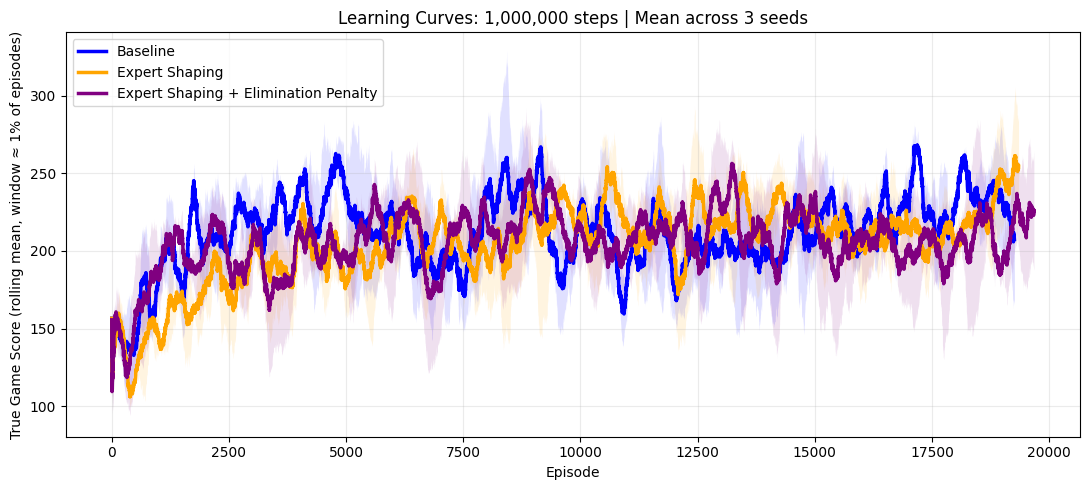


Plotting score distribution (1M aggregated)...


C:\Users\traan\AppData\Local\Temp\ipykernel_3732\4032288448.py:76: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(scores, labels=names, patch_artist=True, showfliers=True)


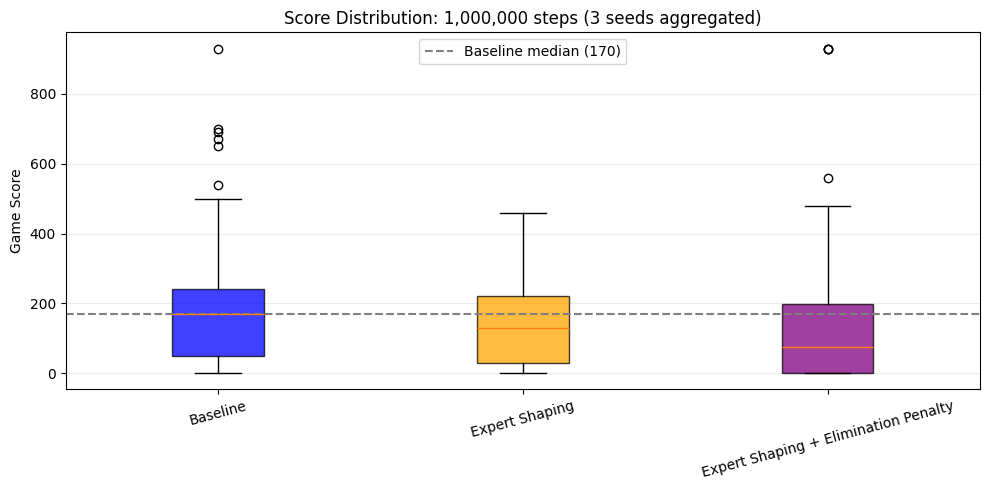

In [24]:
# Learning curves with mean/std shading for multi-seed 1M runs
def plot_learning_curves_multiseed(results_ms, CONDITIONS, total_steps):
    fig, ax = plt.subplots(figsize=(11, 5))
    for name, seed_runs in results_ms.items():
        valid = [r for r in seed_runs if r is not None]
        if not valid:
            continue
        color    = CONDITIONS[name]["color"]
        smoothed = []
        for run in valid:
            rewards = run["episode_rewards"]
            # Window ≈ 1% of episodes keeps smoothing proportional across budgets
            window  = max(1, int(len(rewards) * 0.01))
            s       = pd.Series(rewards).rolling(window, min_periods=1).mean().values
            smoothed.append(s)
        min_len    = min(len(s) for s in smoothed)
        arr        = np.array([s[:min_len] for s in smoothed])
        mean_curve = arr.mean(axis=0)
        std_curve  = arr.std(axis=0)
        x          = np.arange(min_len)
        ax.plot(x, mean_curve, color=color, linewidth=2.5, label=name)
        ax.fill_between(
            x,
            mean_curve - std_curve,
            mean_curve + std_curve,
            color=color, alpha=0.12, linewidth=0,
        )
    ax.set_xlabel("Episode")
    ax.set_ylabel("True Game Score (rolling mean, window ≈ 1% of episodes)")
    ax.set_title(f"Learning Curves: {total_steps:,} steps | Mean across 3 seeds")
    ax.legend()
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(f"plot_learning_curves_{total_steps // 1_000_000}M_multiseed_clean.png", dpi=160)
    plt.show()

if eval_results_1M_agg:
    print("\nPlotting learning curves (1M multi-seed)...")
    plot_learning_curves_multiseed(results_multiseed, CONDITIONS, TOTAL_STEPS_SHORT)
    

# For single-seed mid and long runs, we can only plot the individual curves without mean/std shading
def plot_learning_curves_single(res_dict, CONDITIONS, total_steps, suffix=""):
    fig, ax = plt.subplots(figsize=(11, 5))
    for name, data in res_dict.items():
        if data is None:
            continue
        rewards = data["episode_rewards"]
        window  = max(1, int(len(rewards) * 0.01))
        s       = pd.Series(rewards).rolling(window, min_periods=1).mean()
        ax.plot(s, color=CONDITIONS[name]["color"], linewidth=2, label=name)
    ax.set_xlabel("Episode")
    ax.set_ylabel("True Game Score (rolling mean, window ≈ 1% of episodes)")
    ax.set_title(f"Learning Curves: {total_steps:,} steps{suffix}")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(f"plot_learning_curves_{total_steps // 1_000_000}M.png", dpi=160)
    plt.show()

if eval_results_mid:
    print("\nPlotting learning curves (3M single-seed)...")
    plot_learning_curves_single(results_mid, CONDITIONS, TOTAL_STEPS_MID, suffix=" (single seed)")
if eval_results_long:
    print("\nPlotting learning curves (7M single-seed)...")
    plot_learning_curves_single(results_long, CONDITIONS, TOTAL_STEPS_LONG, suffix=" (single seed)")


# Score distribution boxplots
def plot_score_distribution(eval_res, CONDITIONS, total_steps, suffix=""):
    names  = [name for name in CONDITIONS if name in eval_res]
    scores = [eval_res[name]["scores"] for name in names]
    if not scores:
        return
    fig, ax = plt.subplots(figsize=(10, 5))
    bp = ax.boxplot(scores, labels=names, patch_artist=True, showfliers=True)
    for patch, name in zip(bp["boxes"], names):
        patch.set_facecolor(CONDITIONS[name]["color"])
        patch.set_alpha(0.75)
    if "Baseline" in eval_res:
        baseline_median = float(np.median(eval_res["Baseline"]["scores"]))
        ax.axhline(
            baseline_median,
            linestyle="--", linewidth=1.5, color="gray",
            label=f"Baseline median ({baseline_median:.0f})",
        )
        ax.legend()
    ax.set_ylabel("Game Score")
    ax.set_title(f"Score Distribution: {total_steps:,} steps{suffix}")
    ax.grid(axis="y", alpha=0.25)
    plt.xticks(rotation=15)
    fig.tight_layout()
    fig.savefig(f"plot_score_distribution_{total_steps // 1_000_000}M.png", dpi=160)
    plt.show()

if eval_results_1M_agg:
    print("\nPlotting score distribution (1M aggregated)...")
    plot_score_distribution(eval_results_1M_agg, CONDITIONS, TOTAL_STEPS_SHORT, suffix=" (3 seeds aggregated)")
if eval_results_mid:
    print("\nPlotting score distribution (3M single-seed)...")
    plot_score_distribution(eval_results_mid, CONDITIONS, TOTAL_STEPS_MID, suffix=" (single seed)")
if eval_results_long:
    print("\nPlotting score distribution (7M single-seed)...")
    plot_score_distribution(eval_results_long, CONDITIONS, TOTAL_STEPS_LONG, suffix=" (single seed)")
     